This notebook runs on Different Collections. all are treated as Validation Dataset

Assumptions
- impairment threshold: 5
- jds_average thresh: 4.5

In [2]:
# import necessary packages and libraries
from pandas import DataFrame, Series, read_csv
from numpy import dot, clip, sqrt, mean
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error 
from matplotlib import pyplot as plt
from seaborn import pointplot, violinplot, lineplot, histplot, stripplot
# from tools import plot_confusion_matrix, plot_relative_risk, plot_roc_curve, plot_pr_curve, plot_normalised_relative_risk
import json

In [3]:
# JDS calculation function definition
impairment_thresh = 5  # percent EOO in a JTV session

def calculate_jds_raw(sumstats: Series, model_config: dict) -> Series:
    return clip(dot(sumstats[list(model_config.keys())], list(model_config.values())), 0, 10)

def calculate_jds_average(jds_raw: Series) -> Series:
    return jds_raw.rolling(window=5, min_periods=3).mean()

## data labeling function definition per minute EOO threshold
def get_label(data: Series, eoo_per_minute_thresh: float) -> int:
    if data['eoo_per_minute'] >= eoo_per_minute_thresh:
        return 1
    else:
        return 0

In [4]:
# import model configs
jds_config = read_csv(r"C:\Users\VJain\Optalert Australia\R&D - 5-R&D\530-Investigations\530-150 Video-based Drowsiness Models Evaluation\config\model_configs.csv")
jds_config = jds_config.set_index('variable')
# jds_config

In [5]:
series = jds_config['model_11']
filtered = series[series != 0]
result_dict = filtered.to_dict()
combinations = {'original': result_dict}

#### Get Data

In [6]:
def get_data(path: str, max_window: int) -> DataFrame:
    data = read_csv(path)
    data = data[data.window <= max_window]
    return data

In [7]:
def get_predictons(data: DataFrame, model_config: dict, eoo_per_minute_thresh: float, jds_thresh: float) -> DataFrame:
    data = data.copy()
    data['jds_raw'] = data.apply(calculate_jds_raw, model_config=model_config, axis=1)
    data['jds_average'] = data.groupby('session')['jds_raw'].apply(calculate_jds_average).reset_index(level=0, drop=True)
    data['label'] = data.apply(get_label, eoo_per_minute_thresh=eoo_per_minute_thresh, axis=1)
    data = data.dropna(subset=['jds_average'])
    data.loc[:,'pred'] = data['jds_average'].apply(lambda x: 1 if x >= jds_thresh else 0)
    return data.copy()


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix

def classification_metrics(df, label_col, pred_col, threshold=0.5):
    df = df.dropna(subset=[label_col, pred_col]).copy()  # Drop rows with NaN values in label or prediction columns
    y_true = df[label_col].values
    y_score = df[pred_col].values

    # Convert probabilities to binary predictions
    y_pred = (y_score >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    auc = roc_auc_score(y_true, y_score)

    return {
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": auc
    }


In [9]:
import seaborn as sns
def get_plot(data: DataFrame, jds_thresh: float, auc: float, ax = None):
    data = data.dropna(subset=['label', 'jds_average']).copy()
    sns.stripplot(x='label', y='jds_average', data=data, jitter=True, hue = 'label', s = 3)
    plt.annotate(f"AUC: {auc:.2f}", xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, ha='left', va='top')
    plt.axhline(4.5, color='k', linestyle='--')
    plt.grid(False)
    plt.ylim(-0.05, 10.5)
    plt.show()

In [10]:
from itertools import combinations as it_combinations

def add_feature_combinations(combinations_dict, original_key='original', intercept_key='Constant'):
    """
    Adds all possible feature combinations (always including intercept)
    into the same dictionary.

    Naming format:
        {number_of_features}_{nth}
    """
    combinations_dict = combinations_dict.copy()  # To avoid modifying the original dictionary
    base_dict = combinations_dict[original_key]

    if intercept_key not in base_dict:
        raise ValueError(f"{intercept_key} not found in original dictionary")

    intercept_value = base_dict[intercept_key]

    # Feature keys excluding intercept
    feature_keys = [k for k in base_dict.keys() if k != intercept_key]

    # For tracking nth per feature size
    size_counter = {}

    for r in range(1, len(feature_keys)):
        size_counter[r] = 1

        for combo in it_combinations(feature_keys, r):
            new_dict = {intercept_key: intercept_value}
            for key in combo:
                new_dict[key] = base_dict[key]

            name = f"n_features: {r}, n_Combination{size_counter[r]}"
            combinations_dict[name] = new_dict

            size_counter[r] += 1

    return combinations_dict


In [11]:
combinations

{'original': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173,
  'LnMeanNegativeAVR': -5.0579,
  'LnStdDevNegativeAVR': 1.4008,
  'LnStdDevAVRProduct': 0.6603,
  'LnMeanBTD': 11.0679}}

In [12]:
data_path = r"C:\Users\VJain\Optalert Australia\R&D - 5-R&D\530-Investigations\530-150 Video-based Drowsiness Models Evaluation\data\Collection6_summary_stats_collated_and_labelled_a_geometry.csv"
data = get_data(data_path, max_window=14)
all_combinations_features = add_feature_combinations(combinations)
data = get_predictons(data, combinations['original'], eoo_per_minute_thresh= 5, jds_thresh= 4.5)
metrics = classification_metrics(data, label_col='label', pred_col='jds_average', threshold=4.5)


In [13]:
data

,window,start_time,end_time,blink_count,Constant,EmCount,MeanPositiveZCI,LnMeanPositiveZCI,StdDevPositiveZCI,LnStdDevPositiveZCI,...,NegativeLargeAmpCount,eoo_per_minute,eoo_percent_per_session,session,participant,collection,jds_raw,jds_average,label,pred
3,3,180.0,239.998,29,1,58,124.758621,4.826389,14.846008,2.697798,...,0,0.0,0.000000,20180708_113055,er,Collection6,5.095373,4.918654,0,1
4,4,240.0,299.998,25,1,50,127.760000,4.850161,13.469967,2.600537,...,0,0.0,0.000000,20180708_113055,er,Collection6,5.180215,4.984045,0,1
5,5,300.0,359.998,23,1,46,120.782609,4.794001,11.980881,2.483396,...,0,0.0,0.000000,20180708_113055,er,Collection6,4.233326,4.833901,0,1
6,6,360.0,419.998,31,1,62,126.064516,4.836802,21.924013,3.087628,...,0,0.0,0.000000,20180708_113055,er,Collection6,4.878527,4.805996,0,1
7,7,420.0,479.998,34,1,68,127.470588,4.847894,18.555789,2.920836,...,0,0.0,0.000000,20180708_113055,er,Collection6,4.071396,4.691768,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,10,600.0,659.998,5,1,10,168.000000,5.123970,41.737274,3.731419,...,0,6.0,46.491228,20180704_031107,tm,Collection6,4.083681,6.123115,1,1
2017,11,660.0,719.998,6,1,12,157.000000,5.056252,20.189106,3.005193,...,0,6.0,46.491228,20180704_031107,tm,Collection6,4.024249,5.967348,1,1
2018,12,720.0,779.998,4,1,8,174.000000,5.159061,48.771576,3.887168,...,0,6.0,46.491228,20180704_031107,tm,Collection6,7.981862,5.986973,1,1
2019,13,780.0,839.998,10,1,20,141.800000,4.954425,30.731092,3.425307,...,0,5.0,46.491228,20180704_031107,tm,Collection6,7.622173,6.061344,1,1


In [14]:
# get_plot(data, jds_thresh=4.5, auc=metrics['auc'])

In [15]:
combinations = add_feature_combinations(combinations)

In [19]:
metric_all_cominations = {}
for k in combinations:
    if len(combinations[k]) >= 5:
        df = get_predictons(data, combinations[k], eoo_per_minute_thresh= 5, jds_thresh= 4.5)
        metrics = classification_metrics(df, label_col='label', pred_col='jds_average', threshold=4.5)
        metrics['features'] = combinations[k]
        # if metrics['auc'] != 0.5:
        metric_all_cominations[k] = metrics

In [20]:
metrics

{'sensitivity': np.float64(1.0),
 'specificity': np.float64(0.0),
 'auc': 0.4929955485729248,
 'features': {'Constant': -41.1825,
  'LnMeanNegativeAVR': -5.0579,
  'LnStdDevNegativeAVR': 1.4008,
  'LnStdDevAVRProduct': 0.6603,
  'LnMeanBTD': 11.0679}}

In [ ]:
pd.DataFrame(metric_all_cominations).T

: 

Removing features keeping the constant same is making the constant term overpower the equation. Incorrect way to judge

In [19]:
combinations

{'original': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173,
  'LnMeanNegativeAVR': -5.0579,
  'LnStdDevNegativeAVR': 1.4008,
  'LnStdDevAVRProduct': 0.6603,
  'LnMeanBTD': 11.0679},
 'n_features: 1, n_Combination1': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173},
 'n_features: 1, n_Combination2': {'Constant': -41.1825,
  'LnMeanNegativeAVR': -5.0579},
 'n_features: 1, n_Combination3': {'Constant': -41.1825,
  'LnStdDevNegativeAVR': 1.4008},
 'n_features: 1, n_Combination4': {'Constant': -41.1825,
  'LnStdDevAVRProduct': 0.6603},
 'n_features: 1, n_Combination5': {'Constant': -41.1825, 'LnMeanBTD': 11.0679},
 'n_features: 2, n_Combination1': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173,
  'LnMeanNegativeAVR': -5.0579},
 'n_features: 2, n_Combination2': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173,
  'LnStdDevNegativeAVR': 1.4008},
 'n_features: 2, n_Combination3': {'Constant': -41.1825,
  'LnMeanPositiveZCI': -3.2173,
  'LnStdDevAVRProduct': 0.6603},
 '

## Soft Re-training

In [ ]:
## for one combination, get predictions, calculate metrics and plot
from sklearn.linear_model import LinearRegression
data = get_data(data_path)
data = data.sort_values(['session', 'window'])  # VERY IMPORTANT
features = [_ for _ in combinations['original'].keys() if _ != 'Constant']
model = LinearRegression()
data['label'] = data.apply(get_label, eoo_per_minute_thresh=5, axis=1)
model.fit(data.dropna(subset=features)[features], data.dropna(subset=features)['label'])
data['jds_raw'] = model.predict(data[features])
data['jds_average'] = calculate_jds_average(data['jds_raw'])
# data = data.dropna(subset=['jds_average']).copy()  # Drop rows with NaN values in jds_average
# auc = roc_auc_score(data['label'], data['jds_average'])

TypeError: get_data() missing 1 required positional argument: 'max_window'

: 

In [ ]:
data.head(20)

,window,start_time,end_time,blink_count,Constant,EmCount,MeanPositiveZCI,LnMeanPositiveZCI,StdDevPositiveZCI,LnStdDevPositiveZCI,...,PositiveLargeAmpCount,NegativeLargeAmpCount,eoo_per_minute,eoo_percent_per_session,session,participant,collection,label,jds_raw,jds_average
210,2,120.0,179.998,16,1,32,101.750000,4.622529,13.660161,2.614557,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.046774,NaN
211,3,180.0,239.998,9,1,18,107.111111,4.673876,21.309883,3.059218,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.050176,NaN
212,4,240.0,299.998,13,1,26,115.384615,4.748280,19.738028,2.982598,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.004648,-0.030767
213,5,300.0,359.998,15,1,30,115.466667,4.748991,8.700301,2.163473,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.002336,-0.022491
214,6,360.0,419.998,14,1,28,107.714286,4.679492,11.919141,2.478230,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.025960,-0.023185
215,7,420.0,479.998,16,1,32,110.250000,4.702760,17.616280,2.868880,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.003855,-0.013059
216,8,480.0,539.998,15,1,30,111.333333,4.712538,14.651507,2.684611,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.006931,-0.004410
217,9,540.0,599.998,20,1,40,107.400000,4.676569,7.625442,2.031621,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.023537,-0.010047
218,10,600.0,659.998,15,1,30,122.875000,4.811176,34.082009,3.528799,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.009176,-0.008679
219,11,660.0,719.998,20,1,40,108.842105,4.689907,11.591487,2.450357,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,-0.031878,-0.009863


In [ ]:
## for one combination, get predictions, calculate metrics and plot
auc_for_all_combinations = {}
from sklearn.linear_model import LinearRegression
for k in combinations:
    data = get_data(data_path)
    data = data.sort_values(['session', 'window'])  # VERY IMPORTANT
    features = [_ for _ in combinations[k].keys() if _ != 'Constant']
    model = LinearRegression()
    data['label'] = data.apply(get_label, eoo_per_minute_thresh=5, axis=1)
    data = data.dropna(subset=features + ['label']).copy()  # Drop rows with NaN values in features or label
    model.fit(data[features], data['label'])
    data['jds_raw'] = model.predict(data[features])
    data['jds_average'] = calculate_jds_average(data['jds_raw'])
    data = data.dropna(subset=['jds_average']).copy()  # Drop rows with NaN values in jds_average
    auc = roc_auc_score(data['label'], data['jds_average'])
    auc_for_all_combinations[k] = auc

In [ ]:
data

,window,start_time,end_time,blink_count,Constant,EmCount,MeanPositiveZCI,LnMeanPositiveZCI,StdDevPositiveZCI,LnStdDevPositiveZCI,...,PositiveLargeAmpCount,NegativeLargeAmpCount,eoo_per_minute,eoo_percent_per_session,session,participant,collection,label,jds_raw,jds_average
212,4,240.0,299.998,13,1,26,115.384615,4.748280,19.738028,2.982598,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.018229,-0.011363
213,5,300.0,359.998,15,1,30,115.466667,4.748991,8.700301,2.163473,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.014099,-0.004998
214,6,360.0,419.998,14,1,28,107.714286,4.679492,11.919141,2.478230,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.000034,-0.003991
215,7,420.0,479.998,16,1,32,110.250000,4.702760,17.616280,2.868880,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.023073,0.004637
216,8,480.0,539.998,15,1,30,111.333333,4.712538,14.651507,2.684611,...,0,0,0.0,0.0,20180605_105651,id,Collection6,0,0.011183,0.013324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,11,660.0,719.998,16,1,32,139.625000,4.938967,22.357325,3.107199,...,0,0,0.0,0.0,20180708_232057,er,Collection6,0,0.028060,0.047863
60,12,720.0,779.998,18,1,36,127.777778,4.850300,24.300945,3.190556,...,0,0,0.0,0.0,20180708_232057,er,Collection6,0,0.035058,0.046206
61,13,780.0,839.998,18,1,36,132.222222,4.884492,21.019754,3.045510,...,0,0,0.0,0.0,20180708_232057,er,Collection6,0,0.028934,0.044933
62,14,840.0,899.998,17,1,34,129.444444,4.863260,9.450940,2.246220,...,0,0,0.0,0.0,20180708_232057,er,Collection6,0,0.033456,0.044175


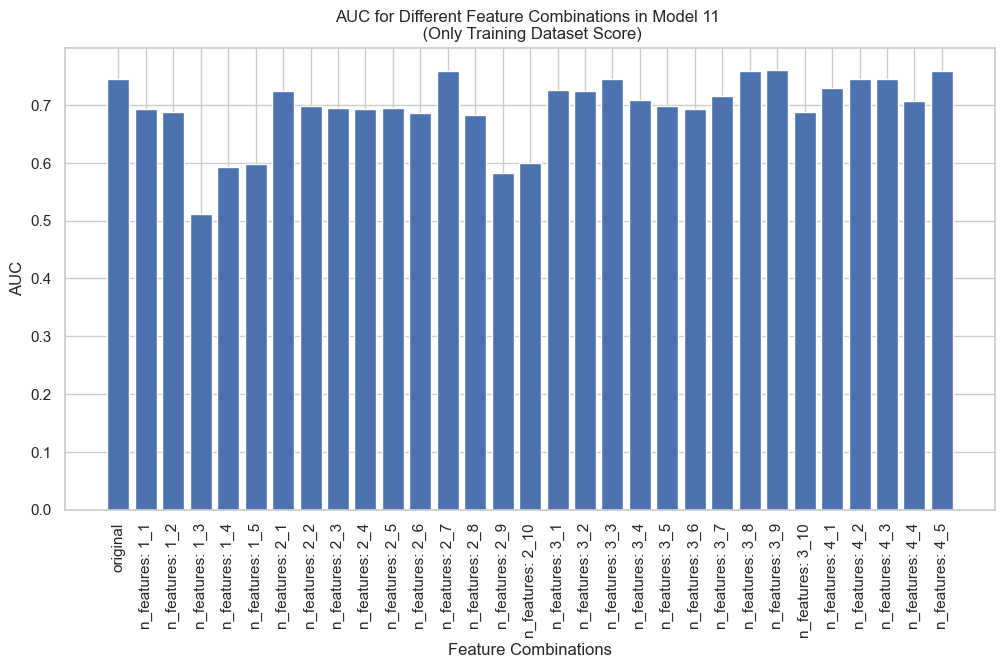

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(auc_for_all_combinations.keys(), auc_for_all_combinations.values())
plt.xticks(rotation=90)
plt.xlabel('Feature Combinations')
plt.ylabel('AUC')
plt.title('AUC for Different Feature Combinations in Model 11 \n (Only Training Dataset Score)');